In [ ]:
import keras
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.applications import MobileNetV2
from keras.datasets import cifar10

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
# CIFAR-10 로드 (3채널 컬러, 10클래스)
(x_train, y_train_raw), (x_test, y_test_raw) = cifar10.load_data()
y_train = y_train_raw.flatten()  # (50000, 1) → (50000,)
y_test = y_test_raw.flatten()

# MobileNetV2 최소 입력 크기 96×96 ? CIFAR-10(32×32)을 리사이즈
x_train_r = tf.image.resize(x_train, [96, 96]) / 255.0
x_test_r = tf.image.resize(x_test, [96, 96]) / 255.0

In [ ]:
print("x_train_r:", x_train_r.shape)
print("y_train:", y_train.shape)
print("x_test_r:", x_test_r.shape)
print("y_test:", y_test.shape)

In [ ]:
classes = [
    "비행기", "자동차", "새", "고양이", "사슴",
    "개", "개구리", "말", "배", "트럭",
]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for class_idx, class_name in enumerate(classes):

    # 해당 클래스 데이터 찾기
    idx = np.flatnonzero(y_train == class_idx)

    # 첫 번째 이미지 선택
    img_idx = idx[0]

    ax = axes[class_idx // 5, class_idx % 5]

    ax.imshow(x_train[img_idx])
    ax.set_title(class_name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

In [ ]:
# 레어어 개수, 파라미터 수
len(base_model.layers), base_model.count_params()

In [ ]:
base_model.trainable = False

In [ ]:
inputs = keras.Input((96,96,3))
x = base_model(inputs, training=False)

x = keras.layers.GlobalAveragePooling2D()(x)
outputs = keras.layers.Dense(10, activation="softmax")(x)

model_tl = keras.Model(inputs, outputs)

In [ ]:
model_tl.summary()

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    "best-model_tl.keras", save_best_only=True
)

early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [16]:
history = model_tl.fit(
    x_train_r, y_train,
    epochs=10, validation_split=0.2,
    batch_size=16, callbacks=[checkpoint, early_stopping]
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 99s 40ms/step - accuracy: 0.7715 - loss: 0.6737 - val_accuracy: 0.8202 - val_loss: 0.5435
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 102s 41ms/step - accuracy: 0.8608 - loss: 0.4008 - val_accuracy: 0.8407 - val_loss: 0.4915
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 0.8997 - loss: 0.2895 - val_accuracy: 0.8467 - val_loss: 0.4760
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - accuracy: 0.9252 - loss: 0.2167 - val_accuracy: 0.8506 - val_loss: 0.4748
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 109s 44ms/step - accuracy: 0.9419 - loss: 0.1664 - val_accuracy: 0.8484 - val_loss: 0.4925
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 107s 43ms/step - accuracy: 0.9549 - loss: 0.1325 - val_accuracy: 0.8476 - val_loss: 0.5622



---
### 파인튜닝

In [17]:
base_model.trainable = True

# base_model의 하위 층은 유지, 상위 30층부터 학습 허용
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"전체 레이어: {len(base_model.layers)}")
print(f"동결 레이어: {fine_tune_at}")
print(f"학습 가능 레이어: {len(base_model.layers) - fine_tune_at}")

전체 레이어: 154
동결 레이어: 124
학습 가능 레이어: 30


In [19]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_ft = model_tl.fit(
    x_train_r, y_train, epochs=10, validation_split=0.2, batch_size=16
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 119s 45ms/step - accuracy: 0.8918 - loss: 0.3182 - val_accuracy: 0.8472 - val_loss: 0.5520
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 114s 46ms/step - accuracy: 0.9441 - loss: 0.1585 - val_accuracy: 0.8464 - val_loss: 0.5736
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 117s 47ms/step - accuracy: 0.9544 - loss: 0.1305 - val_accuracy: 0.8468 - val_loss: 0.5998
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 0.9628 - loss: 0.1083 - val_accuracy: 0.8441 - val_loss: 0.6411
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 109s 44ms/step - accuracy: 0.9677 - loss: 0.0914 - val_accuracy: 0.8597 - val_loss: 0.5955
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 112s 45ms/step - accuracy: 0.9722 - loss: 0.0824 - val_accuracy: 0.8518 - val_loss: 0.6751
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 0.9745 - loss: 0.0747 - val_accuracy: 0.8474 - val_loss: 0.6553
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 108s 43ms/step - accuracy: 

In [20]:
fe_val_acc = max(history.history["val_accuracy"])
ft_val_acc = max(history_ft.history["val_accuracy"])

result_df = pd.DataFrame(
    {
        "학습 방식": ["Feature Extraction", "Fine-Tuning"],
        "최고 val_accuracy": [fe_val_acc, ft_val_acc],
    }
)

result_df

,학습 방식,최고 val_accuracy
0,Feature Extraction,0.8506
1,Fine-Tuning,0.8597


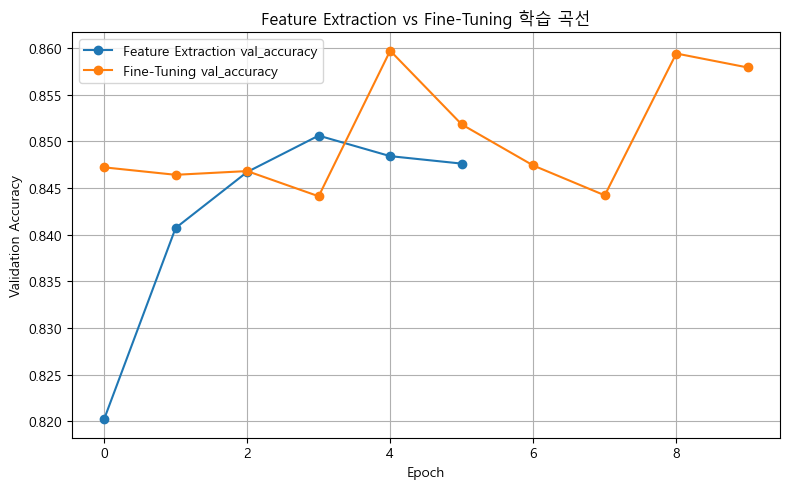

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"], marker="o", label="Feature Extraction val_accuracy"
)

plt.plot(
    history_ft.history["val_accuracy"], marker="o", label="Fine-Tuning val_accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Feature Extraction vs Fine-Tuning 학습 곡선")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()